# Experiment 6:
Implement dual-pivot quicksort and compare its runtime to the provided quicksort on random lists of different sizes. Then Plot the list length vs the time. 

In [ ]:
import sys
sys.setrecursionlimit(20000)  

import time
import matplotlib.pyplot as plt

from auxilary.good_sorts import quicksort
from auxilary.bad_sorts import create_random_list


In [ ]:
def time_sort(sort_fn, arr, runs=5):
    times = []
    for _ in range(runs):
        data = arr[:]  
        t0 = time.perf_counter()
        sort_fn(data)
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return min(times)


In [3]:
def dual_quicksort(L):
    
    copy = dual_quicksort_copy(L)
    for i in range(len(L)):
        L[i] = copy[i]

def dual_quicksort_copy(L):
   
    n = len(L)
    if n <= 1:
        return L[:]  
    if n == 2:
        return L[:] if L[0] <= L[1] else [L[1], L[0]]

    p = L[0]
    q = L[-1]
    if p > q:
        p, q = q, p

    left = []
    middle = []
    right = []

    for x in L[1:-1]:
        if x < p:
            left.append(x)
        elif x > q:
            right.append(x)
        else:
            middle.append(x)

    return dual_quicksort_copy(left) + [p] + dual_quicksort_copy(middle) + [q] + dual_quicksort_copy(right)


In [4]:
import random

def check_correct():
    for n in [0, 1, 2, 5, 10, 50]:
        for _ in range(50):
            arr = [random.randint(0, 100) for _ in range(n)]
            expected = sorted(arr)

            test = arr[:]
            dual_quicksort(test)

            if test != expected:
                print("Mismatch!")
                print("Original:", arr)
                print("Got     :", test)
                print("Expected:", expected)
                return False
    return True

check_correct()


True

In [5]:
runs = 5
max_value = 10**6
n_values = [1000, 2000, 5000, 10000, 20000]


In [6]:
std_times = []
dual_times = []

for n in n_values:
    base = create_random_list(n, max_value)

    std_times.append(time_sort(quicksort, base, runs))
    dual_times.append(time_sort(dual_quicksort, base, runs))

std_times, dual_times


([0.001268200110644102,
  0.002274600090458989,
  0.00878289993852377,
  0.01804129988886416,
  0.04091420001350343],
 [0.0008555999957025051,
  0.002633800031617284,
  0.006175299873575568,
  0.01577429985627532,
  0.02883670013397932])

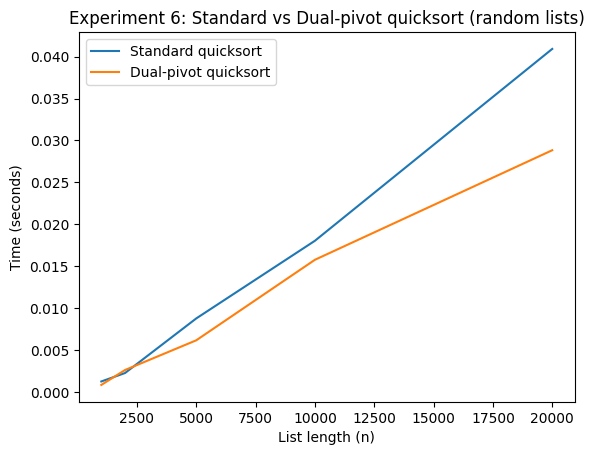

In [7]:
plt.figure()
plt.plot(n_values, std_times, label="Standard quicksort")
plt.plot(n_values, dual_times, label="Dual-pivot quicksort")
plt.xlabel("List length (n)")
plt.ylabel("Time (seconds)")
plt.title("Experiment 6: Standard vs Dual-pivot quicksort (random lists)")
plt.legend()
plt.show()


# Executive Summary

Here are can compare the runtime with the proved quick sort algorithm with my "duel pivot" quick sort algorithm on random lists with size n. The plot shows that dual - pivot quick sort is faster over the almost all if not all of the list of size any N. This sugggests that the extra overhead of using 2 pivots and 3 partiions pays off for inputs sizes that arent very small. 